<a href="https://colab.research.google.com/github/NadiyaNowshin/Exploratory-Data-Analysis-EDA-on-the-Titanic-Dataset/blob/main/Exploratory_Data_Analysis_(EDA)_on_the_Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1**

In [ ]:
#Cell 1: Download and Load Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv

# Load dataset
df = pd.read_csv("titanic.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Cell 2: Check Information
# Information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Cell 3: Descriptive Statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#Cell 4: Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Task 2**

In [ ]:
#Cell 5: Cabin Missing Percentage
cabin_missing = df["Cabin"].isnull().mean() * 100

print("Percentage of missing Cabin values:", cabin_missing, "%")

Percentage of missing Cabin values: 77.10437710437711 %


Decision:
Here, approximately 77% values are missing.As a large proportion of the data is unavailable, filling the Cabin values reliably would be difficult. Therefore, the Cabin column can be dropped from the main analysis

In [ ]:
df = df.drop("Cabin", axis=1)

In [ ]:
#Cell 6: Embarked Missing Values
print("Most frequent port:", df["Embarked"].mode()[0])

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing Embarked values:", df["Embarked"].isnull().sum())

Most frequent port: S
Missing Embarked values: 0


In [ ]:
#Cell 7: Age Missing Values

median_age = df["Age"].median()

print("Median Age:", median_age)

df["Age"] = df["Age"].fillna(median_age)

print("Missing Age values:", df["Age"].isnull().sum())

Median Age: 28.0
Missing Age values: 0


**Task 3**

In [ ]:
#Cell 8: Overall Survival Rate
survival_rate = df["Survived"].mean() * 100

print("Overall Survival Rate:", survival_rate, "%")

Overall Survival Rate: 38.38383838383838 %


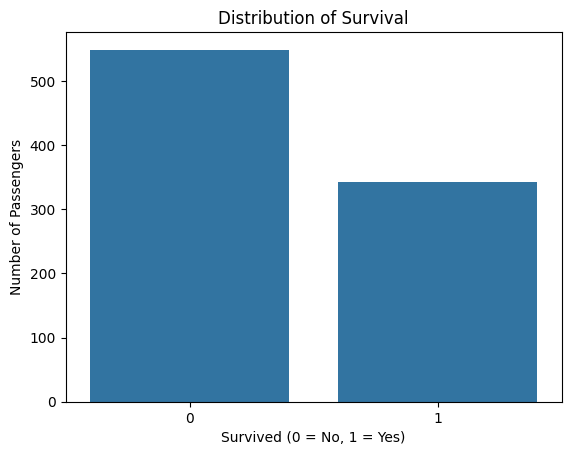

In [ ]:
#Cell 9: Survival Distribution
sns.countplot(x="Survived", data=df)

plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

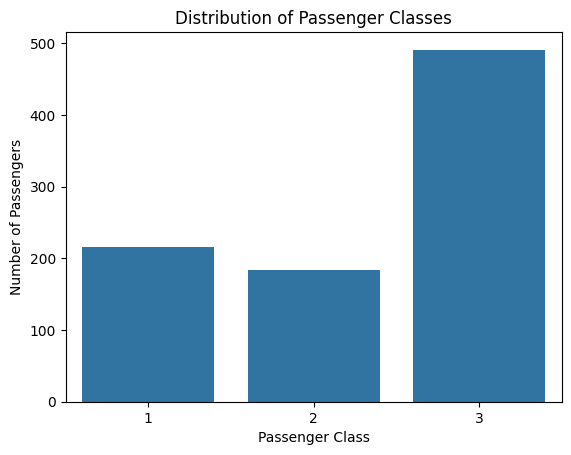

In [ ]:
#Cell 10: Passenger Class Distribution
sns.countplot(x="Pclass", data=df)

plt.title("Distribution of Passenger Classes")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
print(df["Pclass"].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


The 3rd class had the most passengers.

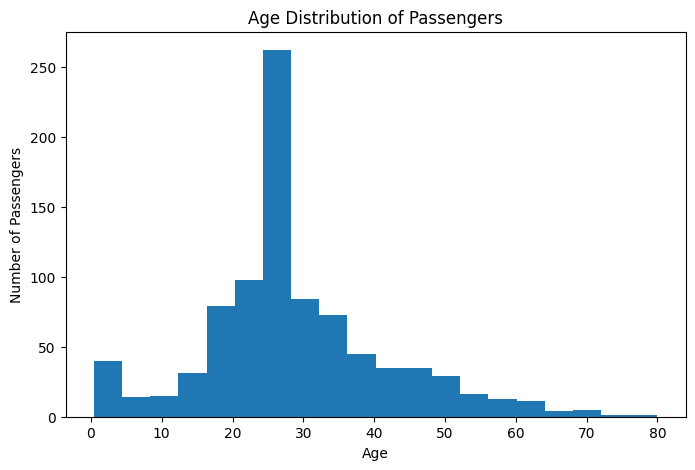

In [ ]:
#Cell 11: Age Distribution
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

**Task 4**

In [ ]:
#Cell 12: Survival by Sex
sex_survival = pd.crosstab(df["Sex"], df["Survived"])

print(sex_survival)

Survived    0    1
Sex               
female     81  233
male      468  109


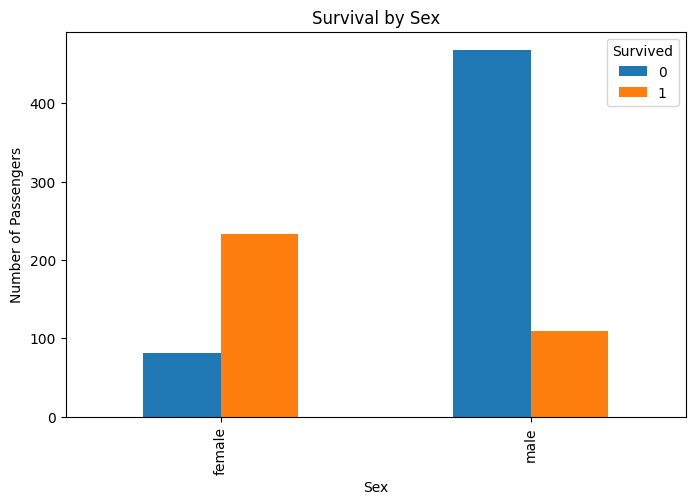

In [ ]:
sex_survival.plot(
    kind="bar",
    stacked=False,
    figsize=(8, 5)
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
sex_survival_rate = df.groupby("Sex")["Survived"].mean() * 100

print(sex_survival_rate)

NameError: name 'df' is not defined

Females had a significantly higher survival rate than males.

In [ ]:
#Cell 13: Survival Rate by Pclass
class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


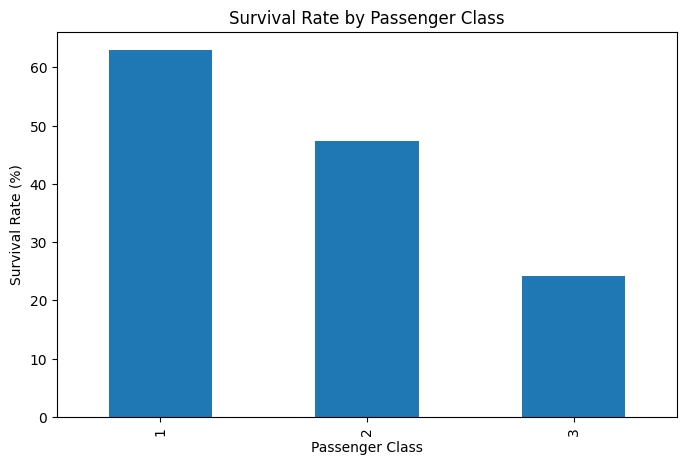

In [ ]:
class_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

Yes, there is a clear relationship between passenger class and survival probability. Passengers in 1st class had the highest survival rate, while passengers in 3rd class had the lowest survival rate.

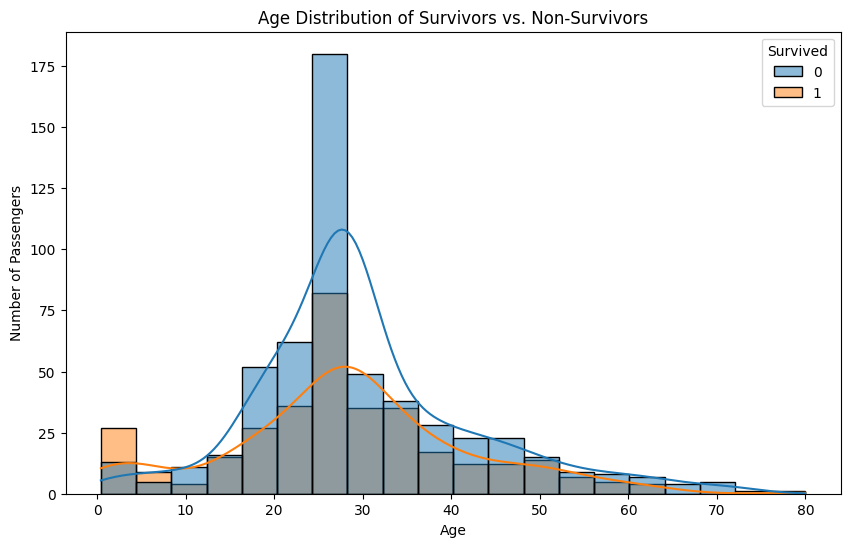

In [ ]:
#Cell 14: Age Distribution of Survivors vs. Non-Survivors
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Survivors vs. Non-Survivors")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

The plot suggests that children had relatively better survival chances than some older age groups, although survival varied considerably across ages. Elderly passengers generally had lower survival chances compared with younger passengers.

In [ ]:
#Cell 15: Survival Rate by Embarked
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100

print(embarked_survival)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


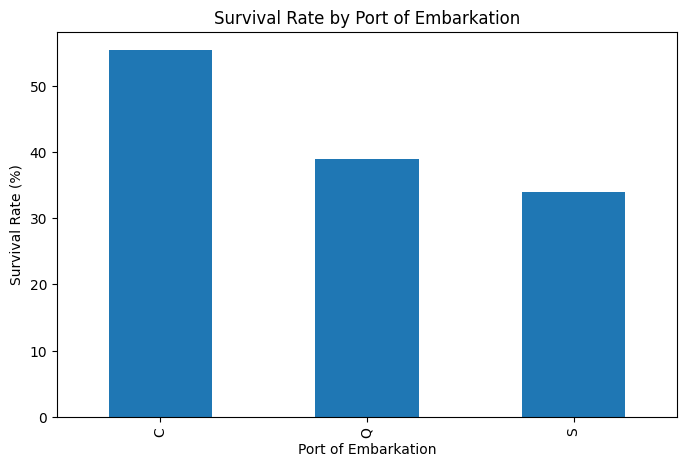

In [ ]:
embarked_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate (%)")

plt.show()

#C = Cherbourg Q = Queenstown S = Southampton

**Task 5**

The EDA shows that sex and passenger class were among the strongest factors associated with survival on the Titanic. Female passengers had a considerably higher survival rate than male passengers, while passengers in 1st class were more likely to survive than those in 2nd or 3rd class. Age also appeared to influence survival, with children showing relatively better survival chances than some older passengers. Overall, Sex, Pclass, and Age appear to be important predictors of passenger survival.